In [1]:
from pathlib import Path
import json, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy.signal import find_peaks

ROOT=Path("/homes/mxqasim/Chocolathon")
RAW=ROOT/"data/boxes/raw"; ANN=ROOT/"data/boxes/annotations"; PROC=ROOT/"data/boxes/processed"; DEBUG=ROOT/"outputs/debug"
for d in (RAW,ANN,PROC,DEBUG): d.mkdir(parents=True,exist_ok=True)

def read_rgb(path): return np.array(ImageOps.exif_transpose(Image.open(path).convert("RGB")))

files=sorted([p for p in RAW.iterdir() if p.suffix.lower() in {".jpg",".jpeg",".png"}])
print(f"Found {len(files)} images")
print(*[p.name for p in files],sep="\n")

Found 16 images
IMG_2019.jpg
IMG_2020.jpg
IMG_2021.jpg
IMG_2022.jpg
IMG_2023.jpg
IMG_2024.jpg
IMG_2025.jpg
IMG_2026.jpg
IMG_2027.jpg
IMG_2028.jpg
IMG_2029.jpg
IMG_2030.jpg
IMG_2031.jpg
IMG_2032.jpg
IMG_2033.jpg
IMG_2034.jpg


In [2]:
SIZE_MAP={}
for i in range(2019,2022): SIZE_MAP[f"IMG_{i}.jpg"]=6
for i in range(2022,2027): SIZE_MAP[f"IMG_{i}.jpg"]=16
for i in range(2027,2031): SIZE_MAP[f"IMG_{i}.jpg"]=30
for i in range(2031,2035): SIZE_MAP[f"IMG_{i}.jpg"]=50

df=pd.DataFrame([{"file":p.name,"box_size":SIZE_MAP.get(p.name)} for p in files])
df

,file,box_size
0,IMG_2019.jpg,6
1,IMG_2020.jpg,6
2,IMG_2021.jpg,6
3,IMG_2022.jpg,16
4,IMG_2023.jpg,16
5,IMG_2024.jpg,16
6,IMG_2025.jpg,16
7,IMG_2026.jpg,16
8,IMG_2027.jpg,30
9,IMG_2028.jpg,30


In [3]:
df.to_csv(ROOT/"data/boxes/manifest.csv",index=False)

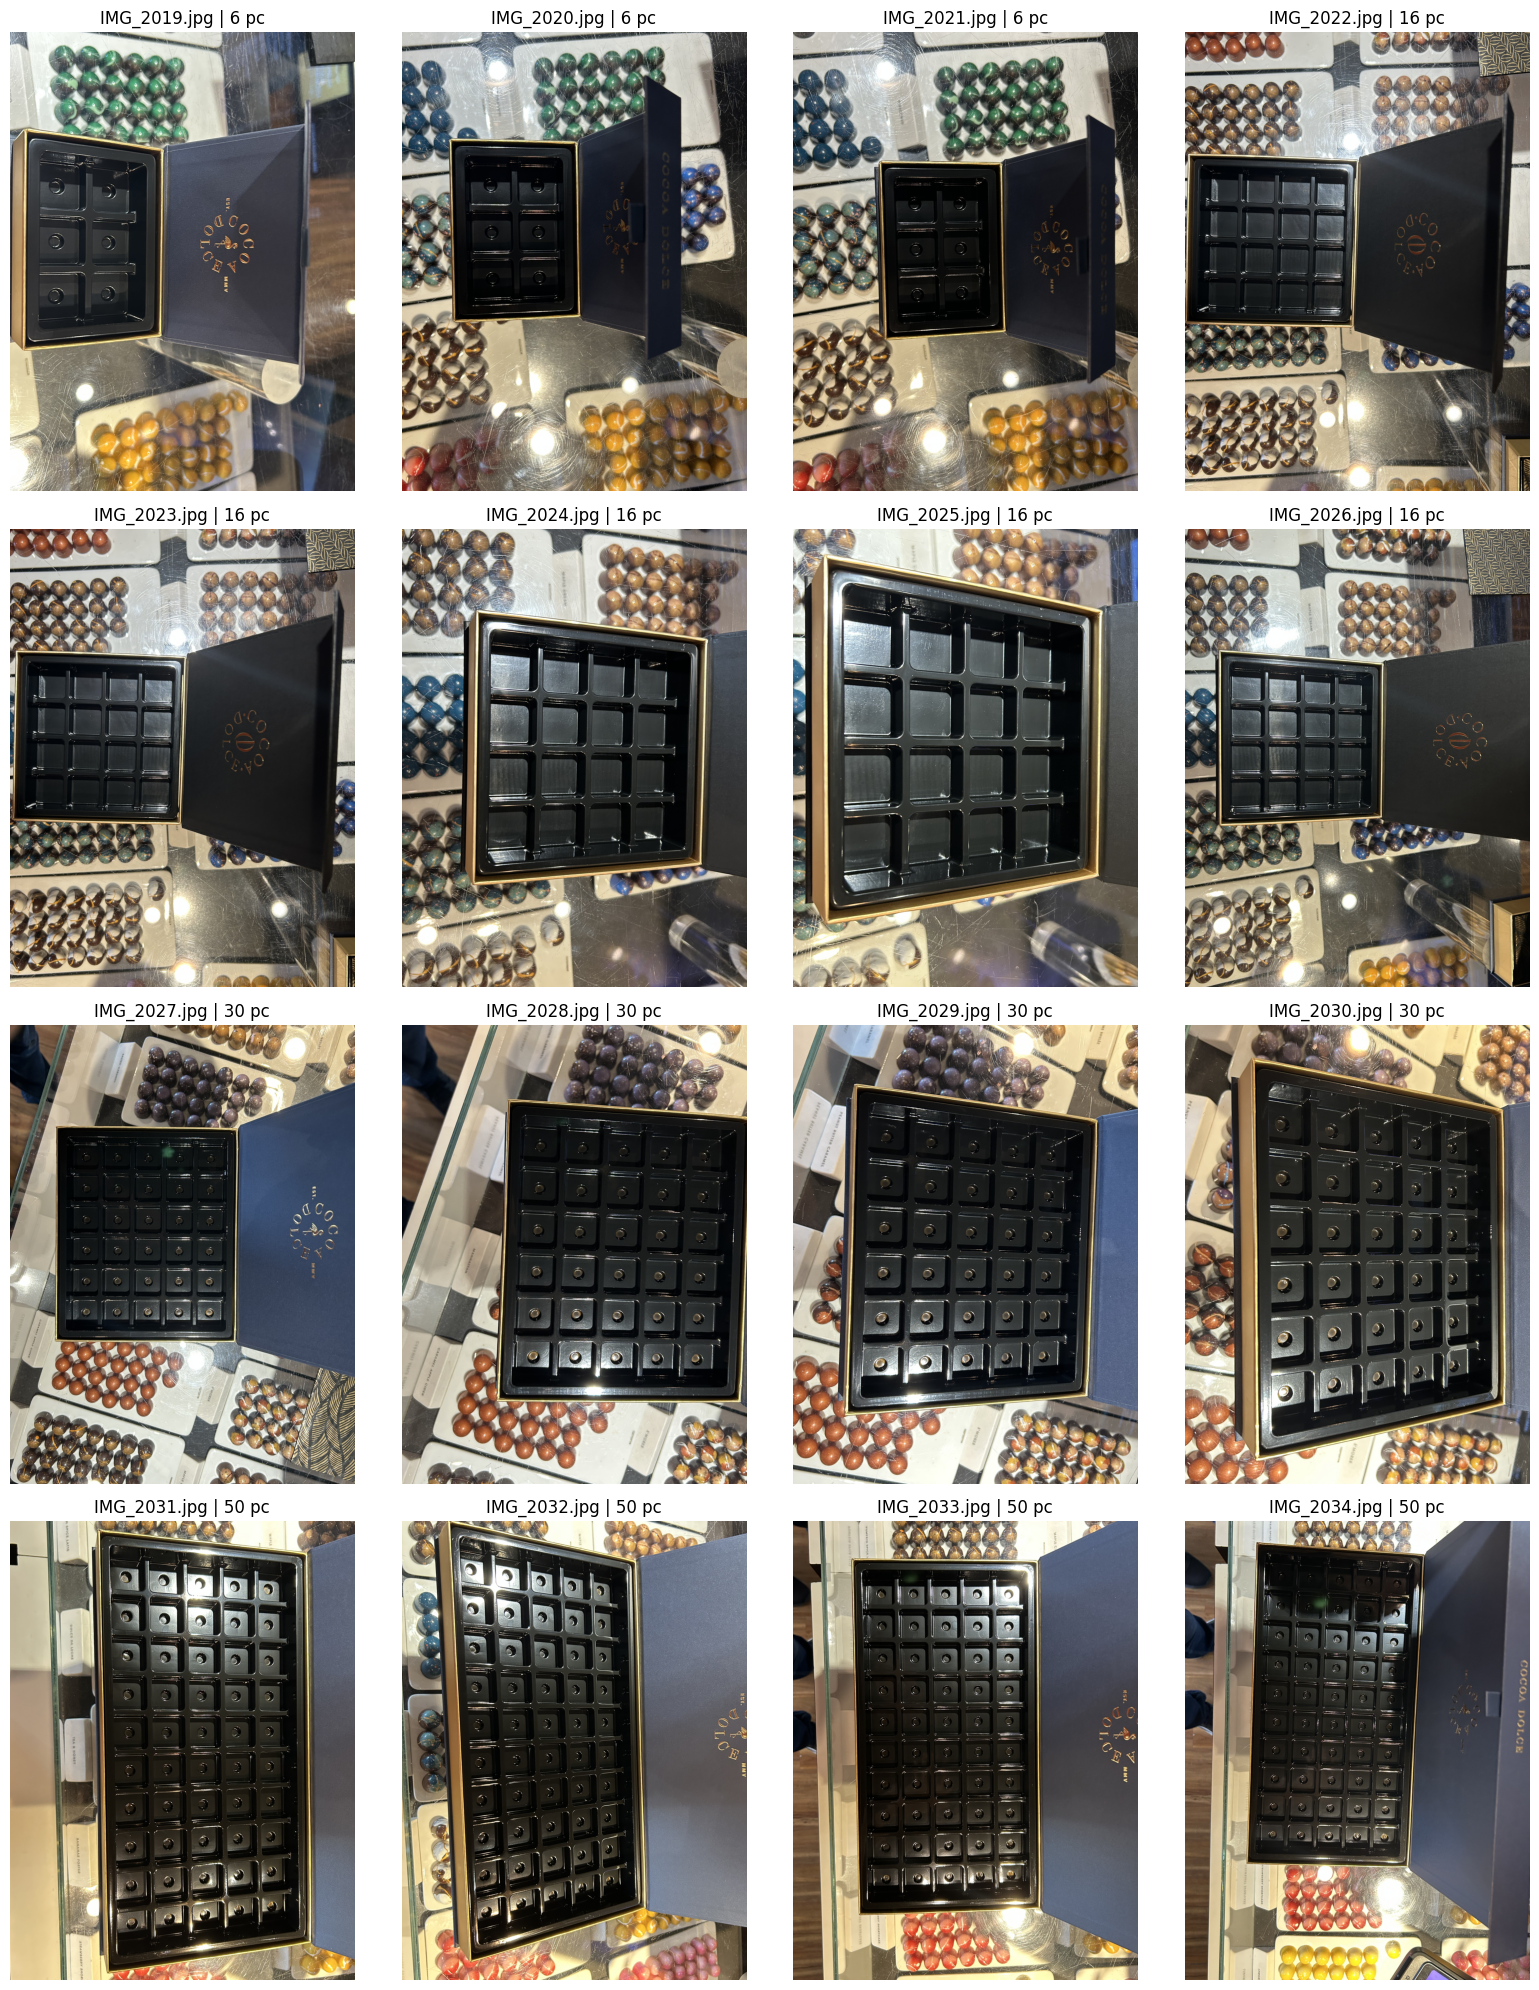

In [4]:
cols=4; rows=int(np.ceil(len(files)/cols))
fig,axs=plt.subplots(rows,cols,figsize=(16,5*rows))

for ax,p in zip(axs.flat,files):
    ax.imshow(read_rgb(p)); ax.set_title(f"{p.name} | {SIZE_MAP[p.name]} pc"); ax.axis("off")

for ax in axs.flat[len(files):]: ax.axis("off")
plt.tight_layout()

In [5]:
for p in files:
    img=read_rgb(p)
    print(f"{p.name:15s} {img.shape[1]} x {img.shape[0]}")

IMG_2019.jpg    3024 x 4032
IMG_2020.jpg    3024 x 4032
IMG_2021.jpg    3024 x 4032
IMG_2022.jpg    3024 x 4032
IMG_2023.jpg    3024 x 4032
IMG_2024.jpg    3024 x 4032
IMG_2025.jpg    3024 x 4032
IMG_2026.jpg    3024 x 4032
IMG_2027.jpg    3024 x 4032
IMG_2028.jpg    3024 x 4032
IMG_2029.jpg    3024 x 4032
IMG_2030.jpg    3024 x 4032
IMG_2031.jpg    3024 x 4032
IMG_2032.jpg    3024 x 4032
IMG_2033.jpg    3024 x 4032
IMG_2034.jpg    3024 x 4032


In [6]:
%matplotlib widget

In [7]:
def annotate_corners(path):
    img=read_rgb(path)
    fig,ax=plt.subplots(figsize=(8,10))
    ax.imshow(img); ax.set_title(f"{Path(path).name}\nClick: TOP-LEFT → TOP-RIGHT → BOTTOM-RIGHT → BOTTOM-LEFT")
    ax.axis("off")
    pts=np.asarray(plt.ginput(4,timeout=0),dtype=np.float32)
    plt.close(fig)
    return pts

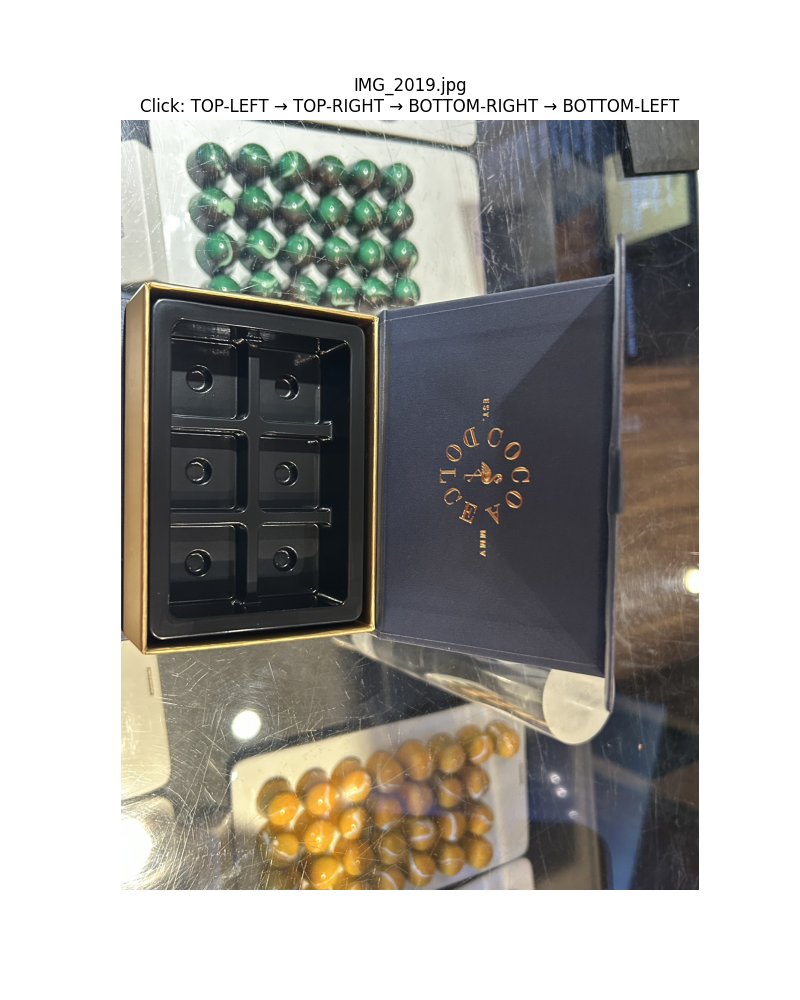

In [ ]:
test_path=RAW/"IMG_2019.jpg"
test_pts=annotate_corners(test_path)
test_pts